# Replicate t-SVGP regression notebook

In [1]:
%load_ext autoreload

%autoreload 2

In [7]:
import numpy as np
import pandas as pd
import jax.numpy as jnp
import jax.scipy as jsp
import jax.random as jr
import matplotlib.pyplot as plt
import optax
from jax import random, jit, value_and_grad
from jax import config
from scipy.optimize import minimize

config.update("jax_enable_x64", True)
%matplotlib inline

In [4]:
import time

from scipy.io import loadmat
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler

In [5]:
from jax_mc_pilco.model_learning.gp.kernels.stationary import ExpSquared, Matern52
from jax_mc_pilco.model_learning.tsvgp.src.models.tsvgp import t_SVGP

## Functions

In [6]:
def data_load(name, split=0.8, seed=0, path="./data/", normalize=False):
    """
    Util function to load the UCI datasets
    """
    np.random.seed(seed)
    df = pd.read_csv(r"" + path + name + ".csv")
    if name == "boston":
        Xo = df[
            [
                "crim",
                "zn",
                "indus",
                "chas",
                "nox",
                "rm",
                "age",
                "dis",
                "tax",
                "ptratio",
                "black",
                "lstat",
            ]
        ].to_numpy()
        Yo = df["medv"].to_numpy().reshape((-1, 1))
    elif name == "concrete":
        Xo = df[["cement", "water", "coarse_agg", "fine_agg", "age"]].to_numpy()
        Yo = df["compressive_strength"].to_numpy().reshape((-1, 1))
    elif name == "airfoil":
        Xo = df[
            [
                "Frequency",
                "AngleAttack",
                "ChordLength",
                "FreeStreamVelocity",
                "SuctionSide",
            ]
        ].to_numpy()
        Yo = df["Sound"].to_numpy().reshape((-1, 1))
    elif name == "ionosphere":
        n = np.genfromtxt(r"" + path + name + ".csv", delimiter=",")
        Xo = n[:, :-1]
        Yo = n[:, -1]
        Yo = np.reshape(Yo, (-1, 1))
    elif name == "sonar":
        n = np.genfromtxt(r"" + path + name + ".csv", delimiter=",")
        Xo = n[:, :-1]
        Yo = n[:, -1]
        Yo = np.reshape(Yo, (-1, 1))
    elif name == "diabetes":
        Xo = df[
            [
                "Pregnancies",
                "Glucose",
                "BloodPressure",
                "SkinThickness",
                "Insulin",
                "BMI",
                "DiabetesPedigreeFunction",
                "Age",
            ]
        ].to_numpy()
        Yo = df["Outcome"].to_numpy().reshape((-1, 1))
    elif name == "german_t":
        numvars = [
            "creditamount",
            "duration",
            "installmentrate",
            "residencesince",
            "age",
            "existingcredits",
            "peopleliable",
            "classification",
        ]
        Xo = df[numvars[:-2]].to_numpy()
        Yo = df["classification"].to_numpy().reshape((-1, 1))
    elif name == "german_n":
        numvars = [
            "existingchecking",
            "duration",
            "credithistory",
            "purpose",
            "creditamount",
            "savings",
            "employmentsince",
            "installmentrate",
            "statussex",
            "otherdebtors",
            "residencesince",
            "property",
            "age",
            "otherinstallmentplans",
            "housing",
            "existingcredits",
            "job",
            "peopleliable",
            "telephone",
            "foreignworker",
            "extra1",
            "extra2",
            "extra3",
            "extra4",
        ]
        Xo = df[numvars].to_numpy()
        Yo = df["classification"].to_numpy().reshape((-1, 1))
    elif name == "wine":
        Xo = df[
            [
                "fixed acidity",
                "volatile acidity",
                "citric acid",
                "residual sugar",
                "chlorides",
                "free sulfur dioxide",
                "total sulfur dioxide",
                "density",
                "pH",
                "sulphates",
                "alcohol",
            ]
        ].to_numpy()
        Yo = df["y_value"].to_numpy().reshape((-1, 1))
    elif name == "naval":
        Xo = df[
            [
                "Lever",
                "Ship speed",
                "Gas Turbine",
                "GT rate",
                "Gas Generator",
                "Starboard Propeller",
                "Port Propeller Torque",
                "Hight Pressure",
                "GT Compressor",
                "GT Compressor",
                "HP Turbine",
                "GT Compressor",
                "GT Compressor",
                "GT exhaust",
                "Turbine",
                "Fuel",
            ]
        ].to_numpy()
        Yo = df["y2"].to_numpy().reshape((-1, 1))
    elif name == "snelson":
        Xo = df["x"].to_numpy().reshape((-1, 1))
        Yo = df["y"].to_numpy().reshape((-1, 1))

    if normalize == True:
        X_scaler = StandardScaler().fit(Xo)
        Y_scaler = StandardScaler().fit(Yo)
        X = X_scaler.transform(Xo)
        Y = Y_scaler.transform(Yo)
    else:
        X = Xo
        Y = Yo

    perm = np.random.permutation(X.shape[0])
    np.take(X, perm, axis=0, out=X)
    np.take(Y, perm, axis=0, out=Y)

    n = Y.shape[0]
    t = int(np.floor(n * split))
    x = X[:t, :]
    y = Y[:t, :]
    xt = X[t:, :]
    yt = Y[t:, :]
    data_train = (x, y)
    data_test = (xt, yt)

    return data_train, data_test

In [8]:
# Define parameters
n_e_steps = 8
n_m_steps = 20
nat_lr = 0.8
adam_lr = 0.1
num_inducing_points = 50

nit = 20
t_nit = n_e_steps * nit + n_m_steps * nit

mb_size = "full"
n_folds = 5

data_name = "airfoil"  # Script can run:'boston' 'airfoil'
optim = "Adam"

In [9]:
key = jr.key(19)

In [3]:
def init_model(n_train):
    models = []
    names = []

    m_tsvgp = t_SVGP(
        kernel=Matern52
            lengthscales=np.ones((1, x.shape[1])) * ell, variance=var
        ),
        likelihood=gpflow.likelihoods.Gaussian(),
        inducing_variable=Z.copy(),
        num_data=n_train,
    )

    # Turn off natural params
    gpflow.set_trainable(m_tsvgp.lambda_1, False)
    gpflow.set_trainable(m_tsvgp.lambda_2_sqrt, False)

    models.append(m_tsvgp)
    names.append("tsvgp")

    return models, names


def run_optim(model, iterations):
    """
    Utility function running the Adam optimizer

    :param model: GPflow model
    :param interations: number of iterations
    """

    # Create an Adam Optimizer action
    logf = []
    nlpd = []

    natgrad_opt = NaturalGradient(gamma=nat_lr)

    if optim == "Adam":
        optimizer = tf.optimizers.Adam(adam_lr)

    elif optim == "SGD":
        optimizer = tf.optimizers.SGD(adam_lr)

    optimizer2 = tf.optimizers.Adam(nat_lr)

    train_iter = iter(train_dataset.batch(mb_size))

    training_loss = model.training_loss_closure(train_iter, compile=True)

    # @tf.function
    def optimization_step_nat(training_loss, variational_params):
        natgrad_opt.minimize(training_loss, var_list=variational_params)

    @tf.function
    def optimization_step_tsvgp(model, training_loss):
        model.natgrad_step(*data, lr=nat_lr)

    @tf.function
    def optimization_step(model, training_loss, params):
        optimizer.minimize(training_loss, var_list=params)

    @tf.function
    def optimization_step2(model, training_loss, params):
        optimizer2.minimize(training_loss, var_list=params)

    for step in range(iterations):
        data = next(train_iter)

        if model.name == "svgp" and model.q_mu.trainable == False:
            variational_params = [(model.q_mu, model.q_sqrt)]

            for i in range(n_e_steps):

                optimization_step_nat(training_loss, variational_params)

            elbo = model.maximum_log_likelihood_objective(data).numpy()
            logf.append(elbo)

            nlpd.append(-tf.reduce_mean(model.predict_log_density((xt, yt))).numpy())

            for j in range(n_m_steps):
                optimization_step(model, training_loss, model.trainable_variables)

        elif model.name == "t_svgp":

            for i in range(n_e_steps):
                optimization_step_tsvgp(model, training_loss)

            elbo = model.maximum_log_likelihood_objective(data).numpy()
            logf.append(elbo)
            nlpd.append(-tf.reduce_mean(model.predict_log_density((xt, yt))).numpy())

            for i in range(n_m_steps):
                optimization_step(model, training_loss, model.trainable_variables)

        else:

            for i in range(n_e_steps):
                variational_params = (
                    model.q_mu.trainable_variables + model.q_sqrt.trainable_variables
                )
                optimization_step2(model, training_loss, variational_params)

            elbo = model.maximum_log_likelihood_objective(data).numpy()
            logf.append(elbo)
            nlpd.append(-tf.reduce_mean(model.predict_log_density((xt, yt))).numpy())

            for i in range(n_m_steps):
                trainable_variables = (
                    model.kernel.trainable_variables
                    + model.likelihood.trainable_variables
                    + model.inducing_variable.trainable_variables
                )

                optimization_step(model, training_loss, trainable_variables)

    return logf, nlpd


ell = 1.0
var = 1.0

if data_name == "elevators":
    # Load all the data
    data = np.array(loadmat("../../demos/data/elevators.mat")["data"])
    X = data[:, :-1]
    Y = data[:, -1].reshape(-1, 1)
else:
    data, test = data_load(data_name, split=1.0, normalize=False)
    X, Y = data

X_scaler = StandardScaler().fit(X)
Y_scaler = StandardScaler().fit(Y)
X = X_scaler.transform(X)
Y = Y_scaler.transform(Y)
N = X.shape[0]
D = X.shape[1]

# Initialize inducing locations to the first M inputs in the dataset
# kmeans = KMeans(n_clusters=M, random_state=0).fit(X)
# Z = kmeans.cluster_centers_
Z = X[:M, :].copy()

kf = KFold(n_splits=n_folds, random_state=0, shuffle=True)

RMSE = np.zeros((nm, n_folds))
ERRP = np.zeros((nm, n_folds))
NLPD = np.zeros((nm, n_folds))
TIME = np.zeros((nm, n_folds))

NLPD_i = np.zeros((nm, nit, n_folds))
LOGF_i = np.zeros((nm, nit, n_folds))

fold = 0
for train_index, test_index in kf.split(X):

    # The data split
    x = X[train_index]
    y = Y[train_index]
    xt = X[test_index]
    yt = Y[test_index]

    if mb_size == "full":
        mb_size = x.shape[0]

    train_dataset = (
        tf.data.Dataset.from_tensor_slices((x, y)).repeat().shuffle(x.shape[0])
    )

    mods, names = init_model(x.shape[0])

    maxiter = ci_niter(nit)

    j = 0

    for m in mods:
        t0 = time.time()
        logf_i, nlpd_i = run_optim(m, maxiter)
        t = time.time() - t0

        nlpd = -tf.reduce_mean(m.predict_log_density((xt, yt))).numpy()
        Eft, _ = m.predict_f(xt, full_output_cov=False)
        rmse = tf.math.sqrt(tf.reduce_mean((yt - Eft) ** 2))

        yp, _ = m.predict_y(xt)
        errp = 1.0 - np.sum((yp > 0.5) == (yt > 0.5)) / yt.shape[0]

        print("NLPD for {}: {}".format(m.name, nlpd))
        print("ERR% for {}: {}".format(m.name, rmse))

        # Store results
        ERRP[j, fold] = rmse
        NLPD[j, fold] = nlpd
        TIME[j, fold] = t

        NLPD_i[j, :, fold] = np.array(nlpd_i)
        LOGF_i[j, :, fold] = np.array(logf_i)

        j += 1

    fold += 1

# Calculate averages and standard deviations
rmse_mean = np.mean(ERRP, 1)
rmse_std = np.std(ERRP, 1)
nlpd_mean = np.mean(NLPD, 1)
nlpd_std = np.std(NLPD, 1)
time_mean = np.mean(TIME, 1)
time_std = np.std(TIME, 1)

elbo_mean = np.mean(LOGF_i, 2)
nlpd_i_mean = np.mean(NLPD_i, 2)

plt.title("ELBO" + "_" + data_name)
plt.plot(range(nit), elbo_mean[0, :][:], label=names[0])
plt.plot(range(nit), elbo_mean[1, :][:], label=names[1])
plt.plot(range(nit), elbo_mean[2, :][:], label=names[2])
plt.legend()
plt.show()

plt.title("NLPD" + "_" + data_name)
plt.plot(range(nit), nlpd_i_mean[0, :][:], label=names[0])
plt.plot(range(nit), nlpd_i_mean[1, :][:], label=names[1])
plt.plot(range(nit), nlpd_i_mean[2, :][:], label=names[2])
plt.legend()
plt.show()


# Report
print("Data: {}, n: {}, m: {}, steps: {}".format(data_name, x.shape[0], mb_size, nit))
print("{:<14} {:^13}   {:^13}  ".format("Method", "NLPD", "RMSE"))

for i in range(len(mods)):
    print(
        "{:<14} {:.3f}+/-{:.3f}   {:.3f}+/-{:.3f}  ".format(
            names[i], nlpd_mean[i], nlpd_std[i], rmse_mean[i], rmse_std[i]
        )
    )

In [6]:
params = {
    "kernel":
    {
        "coefficient": jnp.array(0.9,dtype=jnp.float64),
        "log_scale":jnp.array(0.,dtype=jnp.float64)
    },
    "mean":{},
    "likelihood": 
    {
        "log_diag":jnp.array(-0.5,dtype=jnp.float64)
    }
}

In [7]:
gp = GaussianProcess(ExpSquared,X,y,params)

In [8]:
gp = gp_fit(gp)

In [9]:
f_mu, f_cov = gp.predict(X_test)

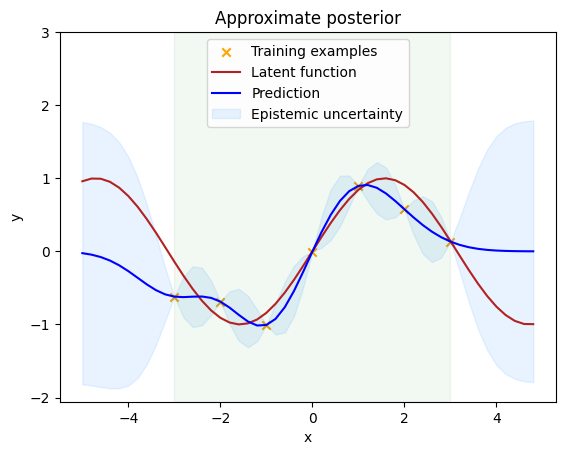

In [10]:
f_test_var = jnp.diag(f_cov)
f_test_std = jnp.sqrt(f_test_var)

plt.scatter(X, y, label='Training examples', marker='x', color='orange')
plt.plot(X_test, f_true, label='Latent function', c='firebrick', lw=1.5)

plt.plot(X_test, f_mu, label='Prediction', c='blue')
plt.fill_between(X_test.ravel(), 
                 f_mu.ravel() + 2 * f_test_std, 
                 f_mu.ravel() - 2 * f_test_std,
                 label='Epistemic uncertainty',
                 color='dodgerblue', alpha=0.1)
plt.title('Approximate posterior')
plt.xlabel('x')
plt.ylabel('y')
plt.ylim(None, 3.0)
plt.legend();
plt.axvspan(X.min(),X.max(),color='green',alpha=0.05);

In [11]:
gp.params

{'kernel': {'coefficient': Array(0.80721709, dtype=float64),
  'log_scale': Array(0.18431621, dtype=float64)},
 'likelihood': {'log_diag': Array(-9.93720866, dtype=float64)},
 'mean': {}}